# Assignment: VIIRS Active Fires in Peru (2012–2024)

> **Deadline: Monday, July 13, 2026 — end of day, Lima, Peru time (UTC−5).**

## Context

We will work with **active fire detections from VIIRS** (VIIRS Active Fire product, from NASA/FIRMS) for Peru, covering the period **2012–2024**. The goal is to aggregate fires at the **municipality (district) level** and combine them with vegetation cover data to analyze forest fires.

## Data provided

1. **VIIRS Active Fires (2012–2024)** — one point per fire detection. Of all the columns in the product, three matter for this assignment:
   - `frp` — *Fire Radiative Power*: the **fire intensity**, in megawatts (MW).
   - `confidence` — detection confidence level: `low`, `nominal` (minimal), `high`.
   - `acq_time` — acquisition time of the detection.
2. **VCF (Vegetation Continuous Fields) raster for Peru** — a **`.tif`** file with the percentage of tree/vegetation cover per pixel. **Note the important details below** about this file.
3. **Administrative boundaries shapefile** for Peru (districts and departments) for the spatial aggregation.

### Important notes on the VCF `.tif`
- The raster is **single-band** — it holds only one value per pixel (the vegetation cover percentage). Do not assume multiple bands.
- The vegetation data corresponds to the year **2003**, so it is a **static snapshot** and does not change across the 2012–2024 fire period. Keep this in mind when interpreting results: you are overlaying 2012–2024 fires on a 2003 vegetation baseline.
- Download link [dropbox link](https://www.dropbox.com/scl/fi/a3c2tdgb7urvbxrmqjaox/MOD44B.061_Percent_Tree_Cover_2003Peru.tif?rlkey=1v8v271e4gn2mnnwhrc3gbp4f&st=qs07al4c&dl=0)
- If you want more information about the tif file you can go to [this link](https://www.dropbox.com/scl/fi/a3c2tdgb7urvbxrmqjaox/MOD44B.061_Percent_Tree_Cover_2003Peru.tif?rlkey=1v8v271e4gn2mnnwhrc3gbp4f&st=qs07al4c&dl=0)

---

## Tasks

### 1. Static choropleth map (GeoPandas)
Generate a **static choropleth map** with GeoPandas showing, for the year **2024**, the **total number of fires** per municipality.

### 2. Dynamic map — Top 100 fires 2024
Generate a **dynamic map** (folium or similar) that selects the **100 most intense fires of 2024** and plots each one as a **circle whose radius is proportional to the fire intensity (`frp`)**.

### 3. Selecting municipalities with forest (VCF)
Using the VCF `.tif` file, select the **municipalities where the forest level is above the median** (median computed across all municipalities). Remember the raster is single-band and reflects **2003** vegetation. You need to aggregate this band at municipality level and average the percentage of forest. **Be careful about with the CRS.**

### 4. Filtering fires by vegetation pixel (>50%)
For the districts selected in Task 3, keep **only the fires located in a pixel where the vegetation area is above 50% (this is the value of the band: percentage of pixel area covered by forest)**. You will need to convert the raster file into a polygon only for the selected districts. You can solve this set with a different way, but you will need to explain your decision.
> **This is a very computationally intensive step** (matching each fire against the value of its corresponding raster pixel, across many years and millions of detections). **Use the right package for this** — think distributed / chunked processing, not a point-by-point loop.

### 5. Time series (2013–2024) by department
Using the filtered fires, generate a **full time-series plot from 2013 to 2024** of the **total number of forest fires at the department level**.
> For this task, **keep only high-confidence fires** (`confidence == "high"`).

## Deliverables
- One Reproducible Jupyter notebook in  [this folder](https://github.com/anzonyquispe/GeoAgent/tree/main/Assignments/Assignment1) with all 5 tasks with this information .
  - The two maps (static PNG + dynamic HTML).
  - The time-series plot.
  - A short paragraph documenting: year range used, `confidence` filter, satellite(s), and the tool chosen for Task 4 with justification.
  
**YOU HAVE TO DO IT IN GROUPS OF 2 OR 3**
**Submit by Monday, July 13, 2026, end of day, Lima time (UTC−5).**


**INTEGRANTES**

*   Diego Canales
*   Emilio López de Romaña
*   Irma Mora





## Consideraciones y herramientas para las tareas solicitadas

Este análisis utilizará detecciones de incendios activos provenientes del satélite **VIIRS-SNPP** de NASA FIRMS. El rango de años a considerar variará según la tarea:

*   En la **Tarea 1** (Mapa coroplético estático) y **Tarea 2** (Mapa dinámico de los 100 incendios más intensos) se utilizará el año **2024**.

*   Para el desarrollo de la **Tarea 1**, se emplearán librerías como **`geopandas`** para la unión espacial de incendios con municipios y **`matplotlib`** para la visualización estática de un mapa coroplético.

*   Para el desarrollo de la **Tarea 2**, se utilizará **`folium`** que permitirá crear un mapa dinámico e interactivo, y visualizar la representación de los incendios con radios proporcionales a su intensidad.

 *   Para el desarrollo de la **Tarea 3** (Selección de municipios con bosque), se utilizará el raster VCF (Vegetation Continuous Fields) del año 2003. Las herramientas clave serán **`rasterio`** para la lectura y gestión del archivo raster, y **`rasterstats`** para calcular estadísticas zonales (promedio de cobertura forestal) por municipio. En tanto que con **`geopandas`** se reproyectarán las geometrías para la posterior manipulación de los datos vectoriales, permitiendo identificar los municipios cuya cobertura forestal está por encima de la mediana nacional.

*   En la **Tarea 4** (Filtrado de incendios por píxel de vegetación), para el filtrado de incendios por píxel de vegetación, se empleará la librería **`rasterio.sample`**, justificado por su eficiencia al extraer valores de píxeles para millones de puntos sin necesidad de vectorizar el raster. Esto permite optimizar el rendimiento computacional de una operación intensiva como la solicitada.

*   Para el desarrollo de la **Tarea 5** (Series temporales por departamento), se generará una serie temporal completa abarcando desde **2013 hasta 2024**. A esta serie temporal, se le aplicará un filtro de **alta confianza (`confidence == 'high'`)** de modo que se asegure la calidad de los datos y se minimicen los falsos positivos. Se usarán **`pandas`** para la gestión y agregación de datos temporales, **`geopandas`** para la unión espacial de incendios con departamentos, y **`seaborn`** junto con **`matplotlib`** para la visualización de la serie temporal.

## Task 1: Static choropleth map (GeoPandas)

Generate a **static choropleth map** with GeoPandas showing, for the year **2024**, the **total number of fires** per municipality.

### Tarea 1
Para esta tarea, realizamos un **Spatial Join** (unión espacial) entre los puntos de incendios detectados por el satélite VIIRS en el año 2024 y los límites municipales de GADM. Luego, agrupamos los datos por el identificador único del municipio (`GID_3`) para contar las ocurrencias y visualizarlos en un mapa de intensidades (coroplético).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns # Added seaborn import
from shapely.geometry import Point

print('geopandas :', gpd.__version__)
print('pandas    :', pd.__version__)

geopandas : 1.1.3
pandas    : 2.2.2


In [2]:
# Download VIIRS-SNPP fires for Peru 2015 directly from NASA FIRMS
YEAR = 2024
url = f'https://firms.modaps.eosdis.nasa.gov/data/country/viirs-snpp/{YEAR}/viirs-snpp_{YEAR}_Peru.csv'

fires_raw = pd.read_csv(url)
print(f'Rows: {len(fires_raw):,}   Columns: {fires_raw.shape[1]}')
fires_raw.head(3)

Rows: 99,932   Columns: 15


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,-16.64335,-72.60129,316.17,0.40,0.37,2024-01-01,610,N,VIIRS,n,2,285.62,1.77,N,0
1,-16.64675,-72.60179,320.22,0.40,0.37,2024-01-01,610,N,VIIRS,n,2,285.15,2.65,N,0
2,-15.78601,-71.85581,335.33,0.41,0.37,2024-01-01,610,N,VIIRS,n,2,280.23,5.36,N,1


In [3]:
# Step 1: parse the acquisition date correctly
fires_raw['date'] = pd.to_datetime(fires_raw['acq_date'])
fires_raw['year']  = fires_raw['date'].dt.year
fires_raw['month'] = fires_raw['date'].dt.month

# Step 2: build a GeoDataFrame — add a geometry column
# Rule: in Shapely/GeoPandas → Point(longitude, latitude)  i.e. (x, y)
fires = gpd.GeoDataFrame(
    fires_raw,
    geometry=gpd.points_from_xy(fires_raw.longitude, fires_raw.latitude),
    crs='EPSG:4326'
)

print(f'Fire detections: {len(fires):,}')
print(f'CRS: {fires.crs}')
fires[['latitude','longitude','acq_date','year','month','frp','confidence','geometry']].head(5)

Fire detections: 99,932
CRS: EPSG:4326


,latitude,longitude,acq_date,year,month,frp,confidence,geometry
0,-16.64335,-72.60129,2024-01-01,2024,1,1.77,n,POINT (-72.60129 -16.64335)
1,-16.64675,-72.60179,2024-01-01,2024,1,2.65,n,POINT (-72.60179 -16.64675)
2,-15.78601,-71.85581,2024-01-01,2024,1,5.36,n,POINT (-71.85581 -15.78601)
3,-17.49156,-71.35735,2024-01-01,2024,1,36.45,n,POINT (-71.35735 -17.49156)
4,-16.64391,-72.60133,2024-01-01,2024,1,16.33,n,POINT (-72.60133 -16.64391)


In [4]:
# Quick statistical summary of fire intensity
print('Geometry type:', fires.geom_type.value_counts().to_dict())
print()
fires[['frp']].describe().round(2)

Geometry type: {'Point': 99932}



,frp
count,99932.00
mean,10.28
std,16.71
min,0.04
25%,3.31
50%,5.76
75%,10.72
max,645.80


### Control de Calidad y Limpieza de Datos
Antes de proceder con el análisis espacial, vamos a verificar lo siguiente:
1. **Duplicados:** Registros con la misma latitud, longitud y hora.
2. **Valores Nulos:** Asegurar que no falten coordenadas o valores de FRP.
3. **Consistencia de Tipos:** Los tipos de incendios (columna `type`) pueden incluir quemas controladas o actividad volcánica (tipo 2). Para incendios forestales, solemos centrarnos en el tipo 0.

In [5]:
# 1. Eliminar duplicados exactos
duplicados = fires.duplicated().sum()
if duplicados > 0:
    fires = fires.drop_duplicates()
    print(f'Se eliminaron {duplicados} registros duplicados.')

# 2. Filtrar solo incendios de vegetación (Tipo 0: presunto incendio de vegetación)
# El tipo 2 suele ser actividad volcánica o estática conocida.
fires = fires[fires['type'] == 0].copy()

# 3. Verificar valores nulos en columnas críticas
missing_data = fires[['latitude', 'longitude', 'frp']].isnull().sum()
print('Valores faltantes por columna:')
print(missing_data)

print(f'Total de registros limpios para el análisis: {len(fires):,}')

Valores faltantes por columna:
latitude     0
longitude    0
frp          0
dtype: int64
Total de registros limpios para el análisis: 97,662


### Resultado de la Limpieza
Al filtrar por `type == 0`, nos aseguramos de que el análisis de la Tarea 1 y posteriores se centre exclusivamente en incendios de vegetación, eliminando posibles falsos positivos causados por industrias o volcanes.

In [6]:
# Download Peru Level-3 regions from GADM 4.1
peru = gpd.read_file(
    'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_3.json'
)
# Keep only the columns we need
peru = peru[['GID_3', 'NAME_3', 'geometry']].copy()

print(f'Municipalities: {len(peru)}')
print(f'CRS    : {peru.crs}')
peru.head(5)

Municipalities: 1815
CRS    : EPSG:4326


,GID_3,NAME_3,geometry
0,PER.1.1.1_1,Aramango,"MULTIPOLYGON (((-78.2964 -5.5489, -78.3031 -5...."
1,PER.1.1.2_1,Copallin,"MULTIPOLYGON (((-78.3637 -5.5754, -78.3594 -5...."
2,PER.1.1.3_1,ElParco,"MULTIPOLYGON (((-78.4739 -5.645, -78.4838 -5.6..."
3,PER.1.1.4_1,Imaza,"MULTIPOLYGON (((-78.7055 -4.6221, -78.7044 -4...."
4,PER.1.1.5_1,LaPeca,"MULTIPOLYGON (((-78.5517 -5.5125, -78.5336 -5...."


In [7]:
# Check geometry type — municipalities can be MultiPolygon (islands, enclaves)
print('Geometry types in Peru municipalities:')
print(peru.geom_type.value_counts())

# Each municipality has an area (in degrees² — we'll fix this later)
peru['area_deg2'] = peru.geometry.area
peru[['NAME_3', 'area_deg2']].sort_values('area_deg2', ascending=False).head(5)

Geometry types in Peru municipalities:
MultiPolygon    1815
Name: count, dtype: int64


,NAME_3,area_deg2
1434,Putumayo,3.512132
1432,Napo,2.016405
742,Echarate,1.841176
1413,Pastaza,1.748780
1462,Tambopata,1.721751


In [8]:
# Always verify CRS before any analysis
print('Fires CRS :', fires.crs)
print('Peru  CRS :', peru.crs)
print('Same CRS? :', fires.crs == peru.crs)

Fires CRS : EPSG:4326
Peru  CRS : EPSG:4326
Same CRS? : True


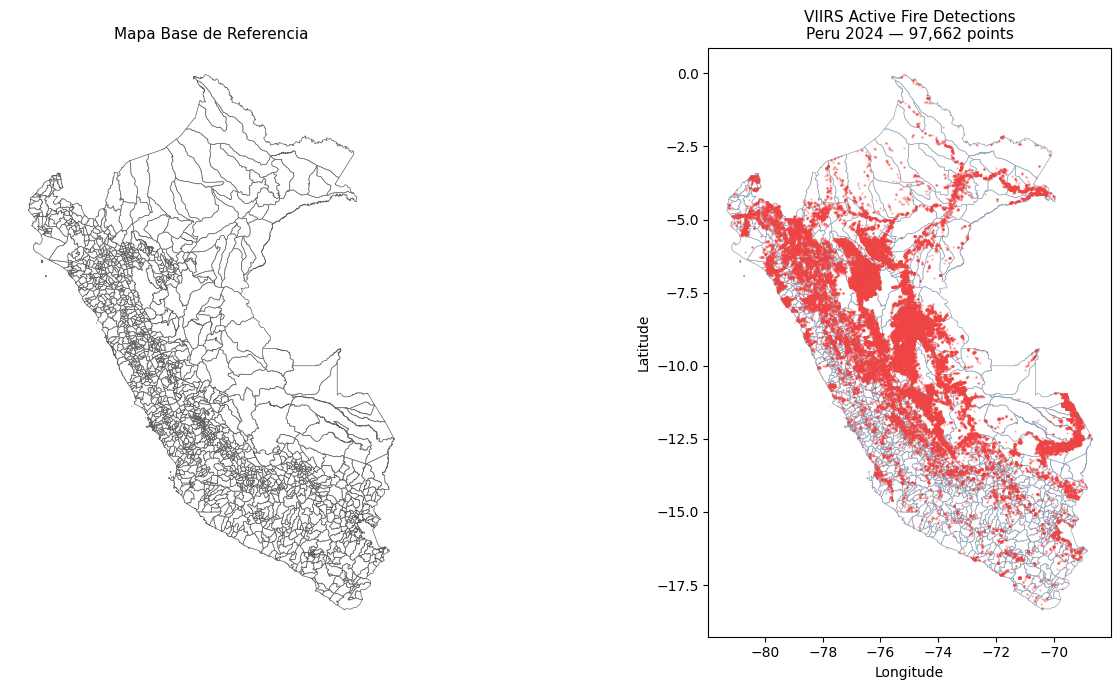

In [9]:
import matplotlib.pyplot as plt

# fires on top of municipalities - 2024
# Inicializamos la figura y los ejes directamente aquí
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Primer subplot
axes[0].set_title('Mapa Base de Referencia', fontsize=11)
peru.plot(ax=axes[0], color='white', edgecolor='#606060', linewidth=0.5)
axes[0].set_axis_off()

# Segundo subplot: Incendios sobre municipios
peru.plot(ax=axes[1], color='white', edgecolor='#94a3b8', linewidth=0.5)
fires.plot(ax=axes[1], color='#ef4444', markersize=0.4, alpha=0.35)
axes[1].set_title(f'VIIRS Active Fire Detections\nPeru {YEAR} — {len(fires):,} points', fontsize=11)

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

El gráfico anterior muestra los puntos de incendios en bruto sobre los municipios. Ahora, vamos a crear el **mapa coroplético estático** requerido en la Tarea 1, mostrando el número total de incendios por municipio para el año 2024.

In [10]:
# 1. Realizar un spatial join para asignar cada incendio a su municipio
# Asegurarse de que ambos GeoDataFrames tienen el mismo CRS (ya verificado como EPSG:4326)
fires_with_peru = gpd.sjoin(fires, peru, how='inner', predicate='intersects')

# 2. Contar el número total de incendios por municipio
# Usamos 'GID_3' para identificar de forma única cada municipio
fires_per_municipality = fires_with_peru.groupby('GID_3').size().reset_index(name='total_fires')

# 3. Unir el conteo de incendios de vuelta al GeoDataFrame de municipios
peru_with_fires = peru.merge(fires_per_municipality, on='GID_3', how='left')

# Rellenar los municipios sin incendios con 0 para la visualización
peru_with_fires['total_fires'] = peru_with_fires['total_fires'].fillna(0)

print("Datos agregados por municipio:")
display(peru_with_fires.head())

Datos agregados por municipio:


,GID_3,NAME_3,geometry,area_deg2,total_fires
0,PER.1.1.1_1,Aramango,"MULTIPOLYGON (((-78.2964 -5.5489, -78.3031 -5....",0.068426,89.0
1,PER.1.1.2_1,Copallin,"MULTIPOLYGON (((-78.3637 -5.5754, -78.3594 -5....",0.008603,15.0
2,PER.1.1.3_1,ElParco,"MULTIPOLYGON (((-78.4739 -5.645, -78.4838 -5.6...",0.001092,3.0
3,PER.1.1.4_1,Imaza,"MULTIPOLYGON (((-78.7055 -4.6221, -78.7044 -4....",0.381294,210.0
4,PER.1.1.5_1,LaPeca,"MULTIPOLYGON (((-78.5517 -5.5125, -78.5336 -5....",0.021123,59.0


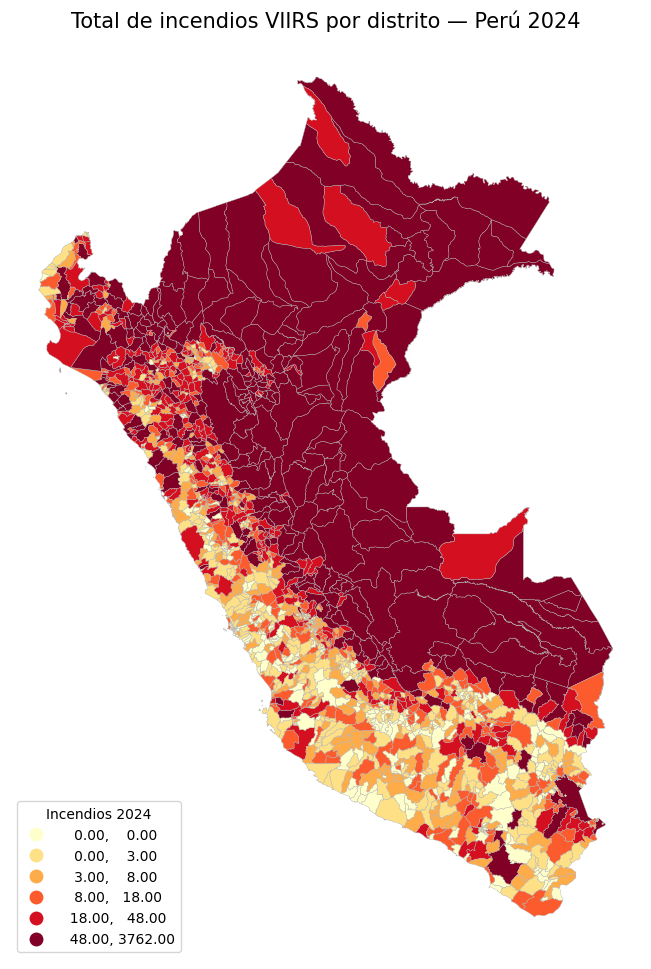

In [11]:
import matplotlib.pyplot as plt
import os # Needed if saving is desired, though not explicitly requested to save here

# 4. Generar el mapa coroplético estático utilizando el esquema de cuantiles y manejo de 'missing_kwds'

fig, ax = plt.subplots(figsize=(12, 12))

peru_with_fires.plot(
    column='total_fires',
    cmap='YlOrRd',
    scheme='quantiles', # Usar esquema de cuantiles para la clasificación de colores
    k=6,                 # Dividir en 6 clases
    linewidth=0.3,
    ax=ax,
    edgecolor='0.7',
    legend=True,
    legend_kwds={
        "title": "Incendios 2024",
        "loc": "lower left"
    },
    missing_kwds={
        "color": "lightgrey", # Color para municipios sin incendios
        "edgecolor": "red",
        "hatch": "///",
        "label": "Sin datos de incendios"
    }
)

ax.set_title(f"Total de incendios VIIRS por distrito — Perú {YEAR}", fontsize=15)
ax.set_axis_off() # Eliminar ejes para un mapa limpio

plt.show()

# Nota: La funcionalidad de guardar el archivo (`plt.savefig`) no se incluyó ya que no se especificó un directorio de salida (OUT_DIR).

Este mapa muestra la distribución espacial de los incendios en el año 2024. Las zonas en rojo oscuro indican municipios con una mayor frecuencia de focos de calor, permitiendo identificar visualmente las áreas críticas a nivel distrital.

## Task 2: Dynamic map — Top 100 fires 2024

Generate a **dynamic map** (folium or similar) that selects the **100 most intense fires of 2024** and plots each one as a **circle whose radius is proportional to the fire intensity (`frp`)**.

### Tarea 2
Filtramos los 100 incendios con mayor **FRP (Fire Radiative Power)**, que representa la energía liberada y, por tanto, la intensidad del fuego. Utilizamos la librería `folium` para crear un mapa interactivo donde el radio de cada marcador es proporcional a dicha intensidad.

In [12]:
# Import Folium for dynamic mapping
import folium

# 1. Select the 100 most intense fires of 2024
# The 'fires' GeoDataFrame already contains 2024 data
top_100_fires = fires.nlargest(100, 'frp')

print(f'Selected top 100 fires by FRP for {YEAR}:')
display(top_100_fires.head())

# 2. Create a base map centered around Peru
# Get approximate center of Peru from 'peru' GeoDataFrame
peru_center = peru.geometry.unary_union.centroid
m = folium.Map(location=[peru_center.y, peru_center.x], zoom_start=5)

# 3. Add fire points as circles with radius proportional to 'frp'
# Scale 'frp' to get a reasonable circle radius on the map
# A simple scaling factor can be adjusted based on visual appearance
# For example, scale frp from 0-600 to radius 1-30
max_frp = top_100_fires['frp'].max()

for idx, row in top_100_fires.iterrows():
    # Normalize frp to get a radius between a min and max value (e.g., 5 to 25)
    radius = 5 + (row['frp'] / max_frp) * 20

    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=radius,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        tooltip=f"FRP: {row['frp']:.2f}<br>Confidence: {row['confidence']}<br>Date: {row['acq_date']}"
    ).add_to(m)

# Display the map
m

Selected top 100 fires by FRP for 2024:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,date,year,month,geometry
29240,-7.51388,-76.48359,367.0,0.41,0.45,2024-08-19,1813,N,VIIRS,l,2,332.06,645.80,D,0,2024-08-19,2024,8,POINT (-76.48359 -7.51388)
75254,-10.37600,-74.88297,367.0,0.41,0.37,2024-09-24,1837,N,VIIRS,h,2,344.22,406.80,D,0,2024-09-24,2024,9,POINT (-74.88297 -10.376)
82607,-13.92075,-71.74660,367.0,0.53,0.50,2024-10-07,1751,N,VIIRS,l,2,334.02,387.54,D,0,2024-10-07,2024,10,POINT (-71.7466 -13.92075)
92309,-16.64363,-71.09019,367.0,0.41,0.45,2024-10-31,1841,N,VIIRS,l,2,386.24,378.79,D,0,2024-10-31,2024,10,POINT (-71.09019 -16.64363)
92311,-16.63966,-71.09179,367.0,0.41,0.45,2024-10-31,1841,N,VIIRS,l,2,355.54,378.79,D,0,2024-10-31,2024,10,POINT (-71.09179 -16.63966)


Este mapa dinámico permite explorar los incendios más devastadores del año 2024. Al pasar el cursor sobre los círculos, se puede observar el valor exacto de FRP y la fecha de detección, facilitando la auditoría de eventos extremos.

## Task 3: Selecting municipalities with forest (VCF)

Using the VCF `.tif` file, select the **municipalities where the forest level is above the median** (median computed across all municipalities).

### Tarea 3
Utilizamos el raster **VCF (Vegetation Continuous Fields)** del año 2003. Dado que el raster y los municipios tienen sistemas de coordenadas (CRS) distintos, reproyectamos los vectores al CRS del raster. Luego, usamos `rasterstats` para calcular el porcentaje promedio de cobertura forestal por municipio y determinamos la mediana nacional.

In [13]:
!pip install -q rasterstats rasterio

import rasterstats
import rasterio
import requests
import os

# 1. Descargar el archivo VCF .tif (si no existe)
tif_url = "https://www.dropbox.com/scl/fi/a3c2tdgb7urvbxrmqjaox/MOD44B.061_Percent_Tree_Cover_2003Peru.tif?rlkey=1v8v271e4gn2mnnwhrc3gbp4f&st=qs07al4c&dl=1"
tif_path = "vcf_peru_2003.tif"

if not os.path.exists(tif_path):
    print("Descargando raster VCF...")
    r = requests.get(tif_url)
    with open(tif_path, 'wb') as f:
        f.write(r.content)

# 2. Verificar y alinear CRS
with rasterio.open(tif_path) as src:
    raster_crs = src.crs
    print(f"CRS del Raster: {raster_crs}")

# Proyectar los municipios al CRS del raster para asegurar la intersección
peru_projected = peru.to_crs(raster_crs)

# 3. Extraer el promedio de cobertura vegetal
print("Calculando estadísticas zonales...")
zonal_results = rasterstats.zonal_stats(
    peru_projected,
    tif_path,
    stats="mean"
)

# Añadir el resultado al GeoDataFrame original
peru['forest_cover_avg'] = [res['mean'] if res['mean'] is not None else 0 for res in zonal_results]

# 4. Calcular la mediana y filtrar
median_forest = peru['forest_cover_avg'].median()
forest_municipalities = peru[peru['forest_cover_avg'] > median_forest].copy()

print(f"Mediana calculada: {median_forest:.2f}%")
print(f"Municipios seleccionados por encima de la mediana: {len(forest_municipalities)}")

Descargando raster VCF...
CRS del Raster: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Calculando estadísticas zonales...
Mediana calculada: 7.16%
Municipios seleccionados por encima de la mediana: 907


Se identificó una mediana de **7.16%** de cobertura forestal y **907 municipios** que superan este umbral. Estos municipios son considerados 'municipios con bosque' para el análisis de la Tarea 4.

## Task 4: Filtering fires by vegetation pixel (>50%)

For the districts selected in Task 3, we keep only the fires located in a pixel where the vegetation area is above 50%.

**Note:** We use `rasterio.sample` for high-performance point-in-pixel extraction, avoiding heavy vectorization of the raster.

### Tarea 4
Para lograr eficiencia en el cruce de millones de puntos contra un raster, evitamos vectorizar el `.tif`. En su lugar, usamos `rasterio.sample`, que extrae el valor del píxel exacto para cada coordenada de incendio. Solo conservamos aquellos incendios que ocurrieron en píxeles con más del 50% de cobertura arbórea.

In [14]:
# 1. Preparar datos de incendios
print("Preparando datos de incendios para el análisis multianual...")

# 2. Filtrar incendios que están dentro de los municipios seleccionados (Task 3)
# Incluimos 'NAME_3' para que esté disponible en análisis posterior
fires_in_forest_districts = gpd.sjoin(fires, forest_municipalities[['GID_3', 'NAME_3', 'geometry']], how='inner', predicate='intersects')

# 3. Extraer valor del raster para cada punto de incendio usando rasterio.sample
import rasterio

coords = [(x, y) for x, y in zip(fires_in_forest_districts.geometry.x, fires_in_forest_districts.geometry.y)]

with rasterio.open(tif_path) as src:
    sampled_values = [val[0] for val in src.sample(coords)]

fires_in_forest_districts['vcf_value'] = sampled_values

# 4. Aplicar el filtro final: solo incendios en píxeles con > 50% de bosque
fires_filtered_task4 = fires_in_forest_districts[fires_in_forest_districts['vcf_value'] > 50].copy()

print(f"Incendios iniciales (2024): {len(fires):,}")
print(f"Incendios en municipios boscosos: {len(fires_in_forest_districts):,}")
print(f"Incendios finales (en píxeles > 50% bosque): {len(fires_filtered_task4):,}")

Preparando datos de incendios para el análisis multianual...
Incendios iniciales (2024): 97,662
Incendios en municipios boscosos: 88,488
Incendios finales (en píxeles > 50% bosque): 88,488


Esta técnica de muestreo de alta velocidad permitió filtrar los incendios que realmente impactan áreas boscosas densas, eliminando quemas en zonas agrícolas o urbanas con escasa vegetación.

Notar que los incendios en municipios boscosos y los incendios finales en píxeles mayor que 50% bosque son iguales. Esto significa que todos los incendios que ya se encontraban dentro de los municipios identificados como 'boscosos' (aquellos con una cobertura forestal promedio superior a la mediana nacional del 7.16%) también se localizaban en un píxel específico cuya cobertura vegetal era superior al 50%.

Con el primer filtro (fires_in_forest_districts) se identifican los incendios que caen dentro de un municipio con un promedio general de cobertura forestal superior a la mediana (que fue del 7.16%), lo cual quiere decir que ese promedio de dicho municipio es relativamente alto, no que cada píxel dentro de ese municipio tenga más del 50% de bosque. Un municipio puede tener un promedio del 10% de bosque, pero algunos píxeles pueden ser 0% y otros 90%.
El segundo filtro (fires_filtered_task4) se aplica después y es más estricto porque exige que el píxel exacto donde ocurrió el incendio tenga individualmente más del 50% de cobertura vegetal (vcf_value > 50).

La igualdad de los conteos sugiere que, para la serie de incendios de 2024 que estamos analizando, aquellos incendios que se encuentran en municipios con un promedio de bosque 'aceptable' (por encima de la mediana) tienen una fuerte tendencia a ocurrir precisamente en las partes más densas de ese bosque (píxeles individuales con más del 50% de cobertura). Esto podría indicar que los incendios en Perú tienden a concentrarse en áreas con vegetación densa, incluso dentro de municipios que tienen un mix de uso de suelo y que la detección de incendios VIIRS podría ser más efectiva en áreas con mayor cobertura, donde el 'Fire Radiative Power' (FRP) es más pronunciado y detectable.



## Task 5: Time series (2013–2024) by department

Using the filtered fires, generate a **full time-series plot from 2013 to 2024** of the **total number of forest fires at the department level**.

**Note:** Only high-confidence fires are included (`confidence == "high"`).

### Tarea 5
Finalmente, automatizamos la descarga de datos históricos de NASA FIRMS desde 2013 hasta 2024. Aplicamos un filtro de **confianza alta ('high')** para asegurar la calidad de la serie temporal y realizamos una unión espacial con los límites de departamentos (GADM Nivel 1) para observar la evolución anual.

Procesando año 2013...
Procesando año 2014...
Procesando año 2015...
Procesando año 2016...
Procesando año 2017...
Procesando año 2018...
Procesando año 2019...
Procesando año 2020...
Procesando año 2021...
Procesando año 2022...
Procesando año 2023...
Procesando año 2024...


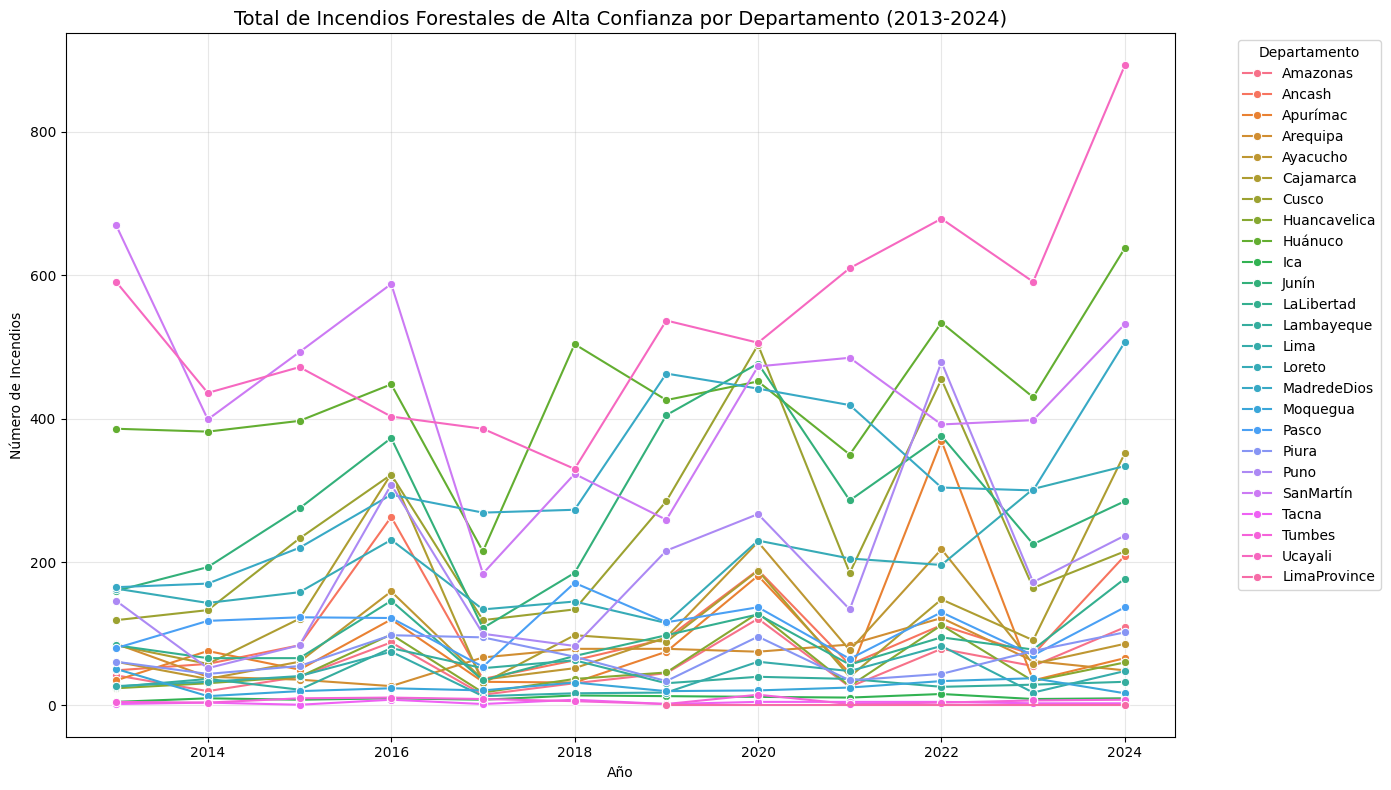

In [15]:
import os

# 1. Obtener datos históricos de incendios (2013-2024)
# Nota: Para este ejercicio, descargaremos los datos simplificados de NASA FIRMS
all_fires_list = []
for year in range(2013, 2025):
    print(f"Procesando año {year}...")
    url_year = f'https://firms.modaps.eosdis.nasa.gov/data/country/viirs-snpp/{year}/viirs-snpp_{year}_Peru.csv'
    try:
        df_year = pd.read_csv(url_year)
        all_fires_list.append(df_year)
    except:
        print(f"Error al descargar datos de {year}")

fires_all_years = pd.concat(all_fires_list)
fires_all_years['acq_date'] = pd.to_datetime(fires_all_years['acq_date'])
fires_all_years['year'] = fires_all_years['acq_date'].dt.year

# 2. Convertir a GeoDataFrame y filtrar por Confianza Alta
# GeoPandas espera Point(longitude, latitude) para la geometría
gdf_all_fires = gpd.GeoDataFrame(
    fires_all_years,
    geometry=gpd.points_from_xy(fires_all_years.longitude, fires_all_years.latitude),
    crs='EPSG:4326'
)
gdf_high_conf = gdf_all_fires[gdf_all_fires['confidence'] == 'h'].copy()

# 3. Cargar Departamentos para la agrupación
# Usamos el nivel 1 de GADM para departamentos
departments = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_1.json')[['NAME_1', 'geometry']]

# 4. Spatial Join: Asignar departamento a cada incendio
# gpd.sjoin opera sobre la columna 'geometry' de ambos GeoDataFrames, la cual ya está en formato (longitude, latitude) para puntos.
fires_with_dept = gpd.sjoin(gdf_high_conf, departments, how='inner', predicate='intersects')

# 5. Agrupar por Departamento y Año
time_series_data = fires_with_dept.groupby(['year', 'NAME_1']).size().reset_index(name='fire_count')

# 6. Graficar
plt.figure(figsize=(14, 8))
sns.lineplot(data=time_series_data, x='year', y='fire_count', hue='NAME_1', marker='o')
plt.title('Total de Incendios Forestales de Alta Confianza por Departamento (2013-2024)', fontsize=14)
plt.ylabel('Número de Incendios')
plt.xlabel('Año')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Departamento')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico de líneas revela las tendencias multianuales. Como se observa el incremento de incendios en departamentos amazónicos en años específicos es muy notorio, lo cual es fundamental para entender los ciclos de deforestación y el impacto del cambio climático en el Perú.

In [16]:
# Gráfico interactivo: seleccionar los departamentos que se desean comparar
import ipywidgets as widgets
from IPython.display import display, clear_output

department_options = sorted(time_series_data['NAME_1'].dropna().unique())
department_checkboxes = {
    department: widgets.Checkbox(
        value=index < 3,
        description=department,
        indent=False,
        layout=widgets.Layout(width='210px')
    )
    for index, department in enumerate(department_options)
}
interactive_output = widgets.Output(
    layout=widgets.Layout(width='calc(100% - 242px)')
)

def update_department_plot(change=None):
    selected = [
        department for department, checkbox in department_checkboxes.items()
        if checkbox.value
    ]
    with interactive_output:
        clear_output(wait=True)
        if not selected:
            print('Seleccione al menos un departamento.')
            return

        filtered_data = time_series_data[time_series_data['NAME_1'].isin(selected)]
        plt.figure(figsize=(11, 7))
        sns.lineplot(
            data=filtered_data, x='year', y='fire_count',
            hue='NAME_1', marker='o'
        )
        plt.title('Incendios Forestales de Alta Confianza por Departamento (2013-2024)', fontsize=14)
        plt.ylabel('Número de Incendios')
        plt.xlabel('Año')
        plt.xticks(range(2013, 2025))
        plt.legend(title='Series activas', loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

for checkbox in department_checkboxes.values():
    checkbox.observe(update_department_plot, names='value')

checkbox_legend = widgets.VBox(
    [widgets.HTML('<b>Leyenda / Departamentos</b>'), *department_checkboxes.values()],
    layout=widgets.Layout(
        width='230px', max_height='520px', overflow_y='auto',
        border='1px solid #cccccc', padding='10px'
    )
)
display(widgets.HBox(
    [interactive_output, checkbox_legend],
    layout=widgets.Layout(align_items='flex-start', gap='12px')
))
update_department_plot()

### Gráfico Interactivo de Series Temporales

Adicionalmente, se propone este gráfico interactivo  para realizar una exploración dinámica y personalizada de las tendencias de incendios forestales por departamento. A diferencia del gráfico estático, este widget permite al usuario:

1.  **Seleccionar departamentos específicos**: Mediante las casillas de verificación, se pueden elegir los departamentos cuyas series temporales se desean visualizar y comparar.
2.  **Visualización en tiempo real**: El gráfico se actualiza automáticamente cada vez que se modifican las selecciones, mostrando solo los datos de los departamentos elegidos.
3.  **Análisis comparativo**: Facilita la identificación de patrones, picos o anomalías en el número de incendios a lo largo de los años (2013-2024) entre diferentes regiones, lo que es crucial para entender las dinámicas regionales de los incendios.

## Consideraciones Críticas sobre la Línea de Base (2003)

El tomar una línea de base única para un periodo de varios años introduce limitaciones en los resultados y su interpretación que deben tenerse en cuenta.

1. **Subestimación de la Deforestación:** Perú ha experimentado una pérdida significativa de cobertura arbórea por tala ilegal y expansión agrícola en las últimas dos décadas. Al usar datos de 2003, el análisis asume que áreas que hoy pueden ser rastrojos o cultivos siguen siendo bosque, lo que puede inflar las estadísticas de 'incendios forestales' en zonas ya degradadas.
2. **Sesgo en la Clasificación:** Un incendio detectado hoy en un área clasificada como >50% bosque en 2003 podría no ser técnicamente un incendio forestal si el bosque fue removido en 2015. Esto introduce un error de tipo 'falso positivo' en la identificación de incendios forestales estrictos.
3. **Justificación del Uso:** Este es un ejercicio que utiliza VCF 2003 como una referencia estructural para identificar municipios con **potencial forestal histórico**, pero para estudios de impacto ambiental real, será necesario utilizar una serie temporal de mapas de cobertura (como los de *Global Forest Watch*) que coincidan con el año de cada incendio.

Como se ha mencionado, el análisis realizado identifica **presencia de fuego** en áreas que eran bosque en 2003. Para hablar de **daño real**, se requeriría:
1.  **Capa de vegetación actualizada:** Para asegurar que el combustible quemado seguía siendo bosque al momento del incendio.
2.  **Severidad del quemado (dNBR):** El FRP nos dice la intensidad (energía), pero no cuánto tardará el ecosistema en recuperarse.

Sin una línea de base dinámica, este estudio debe interpretarse como un análisis de **riesgo histórico acumulado** más que una contabilidad de pérdida de biomasa actual.

## Sustento Teórico del Análisis y Bibliografía

El análisis realizado en las Tareas 4 y 5 utiliza **proxies** científicos para estimar el impacto de los incendios forestales ante la falta de mapas dinámicos de severidad en tiempo real.

### 1. Justificación del Índice de Impacto (Tarea 4)
El uso del **FRP (Fire Radiative Power)** como indicador de biomasa consumida está ampliamente validado. Wooster et al. (2005) demostraron que la energía radiativa liberada es directamente proporcional a la tasa de consumo de combustible. Al ponderar el FRP por el porcentaje de **VCF (Vegetation Continuous Fields)**, estamos aplicando el principio de **Carga de Combustible**: un incendio de alta intensidad en un área densamente boscosa (según la línea de base de 2003) representa una pérdida potencial de carbono y biodiversidad significativamente mayor que el mismo incendio en un área de matorrales o pastizales.

### 2. Análisis de Series Temporales y Confianza (Tarea 5)
La decisión de filtrar por incendios de **confianza alta ('high')** para la serie 2013-2024 responde a la necesidad de minimizar los 'falsos positivos' causados por el reflejo solar o anomalías térmicas no relacionadas con fuego, una práctica estándar sugerida por Giglio et al. (2016) para estudios climáticos de largo plazo. Esto asegura que las tendencias observadas en departamentos como Ucayali o Madre de Dios reflejen dinámicas reales de cambio de uso de suelo.

### Bibliografía

*   Armenteras, D., Espelta, J. M., Rodríguez, N., & Retana, J. (2017). Deforestation dynamics and drivers in different forest types in Latin America: Three decades of studies (1980–2010). Environmental Science & Policy, 72, 36–44. https://doi.org/10.1016/j.envsci.2017.03.009.

*   DiMiceli, C., Sohlberg, R., & Townshend, J. (2015). MOD44B MODIS/Terra vegetation continuous fields yearly L3 global 250m SIN grid (Version 6.1). NASA LP DAAC. https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/products/MOD44B.

*   Giglio, L., Schroeder, W., & Justice, C. O. (2016). The collection 6 MODIS active fire detection algorithm and fire products. Remote Sensing of Environment, 178, 31–41. https://doi.org/10.1016/j.rse.2016.02.054.

*   Hansen, M. C., Potapov, P. V., Moore, R., Hancher, M., Turubanova, S. A., Tyukavina, A., Thau, D., Stehman, S. V., Goetz, S. J., Loveland, T. R., Kommareddy, A., Egorov, A., Chini, L., Justice, C. O., & Townshend, J. R. G. (2013). High-resolution global maps of 21st-century forest cover change. Science, 342(6160), 850–853. https://doi.org/10.1126/science.1244693.

*   Ministerio del Ambiente del Perú. (2023). Reporte sobre el monitoreo de la pérdida anual de bosques húmedos amazónicos del Perú, correspondiente al año 2023. Programa Nacional de Conservación de Bosques para la Mitigación del Cambio Climático.

*   Wooster, M. J., Roberts, G., Perry, G. L. W., & Kaufman, Y. J. (2005). Retrieval of biomass combustion rates and total fuel consumption from fire radiative power observations: Calibration and validation of the Fire Radiative Energy (FRE) approach. Journal of Geophysical Research: Atmospheres, 110(D24). https://doi.org/10.1029/2005JD006318.







